In [30]:
# === Cell 1: Configuration ===

import numpy as np

# --- Data paths (relative to this notebook) ---
DATA_DIR = "../Large Scale/bmDCA"
PF1 = "PF00004"                       # Protein family 1
PF2 = "PF00041"                       # Protein family 2

PARAMS_FILE_1 = f"{DATA_DIR}/{PF1}/{PF1}_params.dat"
PARAMS_FILE_2 = f"{DATA_DIR}/{PF2}/{PF2}_params.dat"
NAT_ENERGIES_FILE_1 = f"{DATA_DIR}/{PF1}/{PF1}_naturalenergies.txt"
NAT_ENERGIES_FILE_2 = f"{DATA_DIR}/{PF2}/{PF2}_naturalenergies.txt"

# --- Overlap length (nucleotides) ---
OVERLAP_LEN = 62

# --- Random seed ---
SEED = 42

# --- Temperature grid ---
# Coarse grid for good swap rates (~30-50%) and efficient exploration.
# 10x10 = 100 replicas covers a wide range; interpolation smooths the result.
T1_MIN, T1_MAX, N_T1 = 0.7, 0.85, 10  # T1 grid for protein 1
T2_MIN, T2_MAX, N_T2 = 0.75, 0.95, 10  # T2 grid for protein 2

# --- 2D Replica Exchange MC parameters ---
RE2D_BURNIN         = 200_000   # Burn-in MC steps per replica
RE2D_SAMPLES        = 10000     # Number of energy samples to collect
RE2D_SAMPLE_INTERVAL = 200      # MC steps between successive samples
RE2D_SWAP_INTERVAL   = 50       # MC steps between replica-swap attempts

# --- Z-score normalization ---
# Set to the natural-energy std of each family to rescale energies so
# that E/nat_std ~ N(0,1).  Use 1.0 for raw (un-normalised) mode.
NAT_STD1 = 1.0                  # 1.0 = raw mode
NAT_STD2 = 1.0                  # 1.0 = raw mode

### Z-score normalization                                                                                                                                                                                                                                                                                                                                                           
  The Metropolis criterion combines energies from both proteins as:                                                                                                                        
  
  $$\Delta H = \frac{\Delta E_1}{\text{nat\_std}_1 \cdot T_1} + \frac{\Delta E_2}{\text{nat\_std}_2 \cdot T_2}$$

  When `NAT_STD = 1.0` (raw mode), temperatures are in raw energy units. Since the two proteins have different natural energy scales (PF00004 std=38.25, PF00041 std=17.64), the same      
  temperature means different things for each — hence the asymmetric T ranges.

  Setting `NAT_STD1 = std_1` and `NAT_STD2 = std_2` normalizes both energy terms to z-scores before temperature scaling, so $T=1$ means "one standard deviation of natural variation" for  
  both proteins. This allows using a single symmetric temperature range for both axes and makes results transferable across protein pairs without re-tuning.

In [31]:
# === Cell 2: Data Loading & JIT Warmup ===

import sys, os, time

sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))
from overlappingGenes import (
    extract_params, load_natural_energies, initial_seq_no_stops,
    seq_str_to_int_array, run_2d_replica_exchange
)

# Load DCA parameters
Js_1, hs_1 = extract_params(PARAMS_FILE_1)
Js_2, hs_2 = extract_params(PARAMS_FILE_2)
DCA_params_1 = [Js_1, hs_1]
DCA_params_2 = [Js_2, hs_2]

lenprot1 = len(hs_1) / 21
lenprot2 = len(hs_2) / 21
print(f"Protein 1 ({PF1}): {int(lenprot1)} AA, {int(3*lenprot1)} nt")
print(f"Protein 2 ({PF2}): {int(lenprot2)} AA, {int(3*lenprot2)} nt")
print(f"Overlap: {OVERLAP_LEN} nt")

# Load natural energies and compute stats
nat_energies_1 = np.array(load_natural_energies(NAT_ENERGIES_FILE_1))
nat_energies_2 = np.array(load_natural_energies(NAT_ENERGIES_FILE_2))
mean_1, std_1 = np.mean(nat_energies_1), np.std(nat_energies_1)
mean_2, std_2 = np.mean(nat_energies_2), np.std(nat_energies_2)
print(f"\nNatural energy stats:")
print(f"  {PF1}: mean={mean_1:.2f}, std={std_1:.2f} (n={len(nat_energies_1)})")
print(f"  {PF2}: mean={mean_2:.2f}, std={std_2:.2f} (n={len(nat_energies_2)})")

np.random.seed(SEED)

# JIT warmup: tiny 2x2 run to compile all numba functions
print("\nJIT warmup (2D RE)...")
t0 = time.time()
_ = run_2d_replica_exchange(
    DCA_params_1, DCA_params_2,
    lenprot1, lenprot2, OVERLAP_LEN,
    T1_grid=np.array([0.5, 1.0]),
    T2_grid=np.array([0.5, 1.0]),
    n_burnin=50, n_samples=5, sample_interval=10,
    swap_interval=10,
    nat_std1=1.0, nat_std2=1.0
)
print(f"JIT warmup done in {time.time() - t0:.1f}s")

Protein 1 (PF00004): 110 AA, 330 nt
Protein 2 (PF00041): 74 AA, 222 nt
Overlap: 62 nt

Natural energy stats:
  PF00004: mean=145.88, std=38.25 (n=213960)
  PF00041: mean=120.66, std=17.64 (n=701132)

JIT warmup (2D RE)...
2D RE: 2x2 = 4 replicas
  T1 range: [0.500, 1.000]
  T2 range: [0.500, 1.000]
  Burn-in: 50, Samples: 5, Sample interval: 10, Swap interval: 10


2D RE: 100%|██████████| 100/100 [00:00<?, ?step/s]

2D RE completed in 0.00s (5 samples collected)
  Mean swap rate H: 0.500, V: 0.250
JIT warmup done in 0.0s


In [32]:
# === Cell 3: 2D RE Grid Scan ===

from scipy.stats import ks_2samp, wasserstein_distance

T1_RANGE = np.linspace(T1_MIN, T1_MAX, N_T1)
T2_RANGE = np.linspace(T2_MIN, T2_MAX, N_T2)

np.random.seed(SEED)

result_2d = run_2d_replica_exchange(
    DCA_params_1, DCA_params_2,
    lenprot1, lenprot2, OVERLAP_LEN,
    T1_grid=T1_RANGE, T2_grid=T2_RANGE,
    n_burnin=RE2D_BURNIN, n_samples=RE2D_SAMPLES,
    sample_interval=RE2D_SAMPLE_INTERVAL,
    swap_interval=RE2D_SWAP_INTERVAL,
    nat_std1=NAT_STD1, nat_std2=NAT_STD2,
)

# --- Compute metrics over the returned E1_grid / E2_grid ---
n_t2, n_t1 = len(T2_RANGE), len(T1_RANGE)
ks_grid   = np.full((n_t2, n_t1), np.nan)
wass_grid = np.full((n_t2, n_t1), np.nan)
zscore_grid = np.full((n_t2, n_t1), np.nan)

for i in range(n_t2):
    for j in range(n_t1):
        e1 = result_2d['E1_grid'][i, j]
        e2 = result_2d['E2_grid'][i, j]

        ks1 = ks_2samp(nat_energies_1, e1).statistic
        ks2 = ks_2samp(nat_energies_2, e2).statistic
        ks_grid[i, j] = (ks1 + ks2) / 2

        w1 = wasserstein_distance(nat_energies_1, e1)
        w2 = wasserstein_distance(nat_energies_2, e2)
        wass_grid[i, j] = (w1 + w2) / 2

        z1 = np.mean(np.abs((e1 - mean_1) / std_1))
        z2 = np.mean(np.abs((e2 - mean_2) / std_2))
        zscore_grid[i, j] = z1 + z2

# --- Find best (T1, T2) per metric ---
def find_best(grid, T1_range, T2_range):
    idx = np.nanargmin(grid)
    i, j = np.unravel_index(idx, grid.shape)
    return T2_range[i], T1_range[j], grid[i, j], i, j

best_ks_T2,   best_ks_T1,   best_ks_val,   ki, kj     = find_best(ks_grid,   T1_RANGE, T2_RANGE)
best_wass_T2, best_wass_T1, best_wass_val, wi, wj     = find_best(wass_grid, T1_RANGE, T2_RANGE)
best_z_T2,    best_z_T1,    best_z_val,    zi, zj     = find_best(zscore_grid, T1_RANGE, T2_RANGE)

print(f"\nBest temperatures:")
print(f"  KS:          T1={best_ks_T1:.3f}, T2={best_ks_T2:.3f} (KS={best_ks_val:.4f})")
print(f"  Wasserstein:  T1={best_wass_T1:.3f}, T2={best_wass_T2:.3f} (W={best_wass_val:.2f})")
print(f"  Z-score:      T1={best_z_T1:.3f}, T2={best_z_T2:.3f} (Z={best_z_val:.3f})")

2D RE: 10x10 = 100 replicas
  T1 range: [0.700, 0.850]
  T2 range: [0.750, 0.950]
  Burn-in: 200000, Samples: 10000, Sample interval: 200, Swap interval: 50


2D RE: 100%|██████████| 2200000/2200000 [00:25<00:00, 86855.13step/s]

2D RE completed in 25.33s (10000 samples collected)
  Mean swap rate H: 0.760, V: 0.778



Best temperatures:
  KS:          T1=0.783, T2=0.839 (KS=0.1505)
  Wasserstein:  T1=0.783, T2=0.839 (W=8.90)
  Z-score:      T1=0.817, T2=0.861 (Z=1.015)


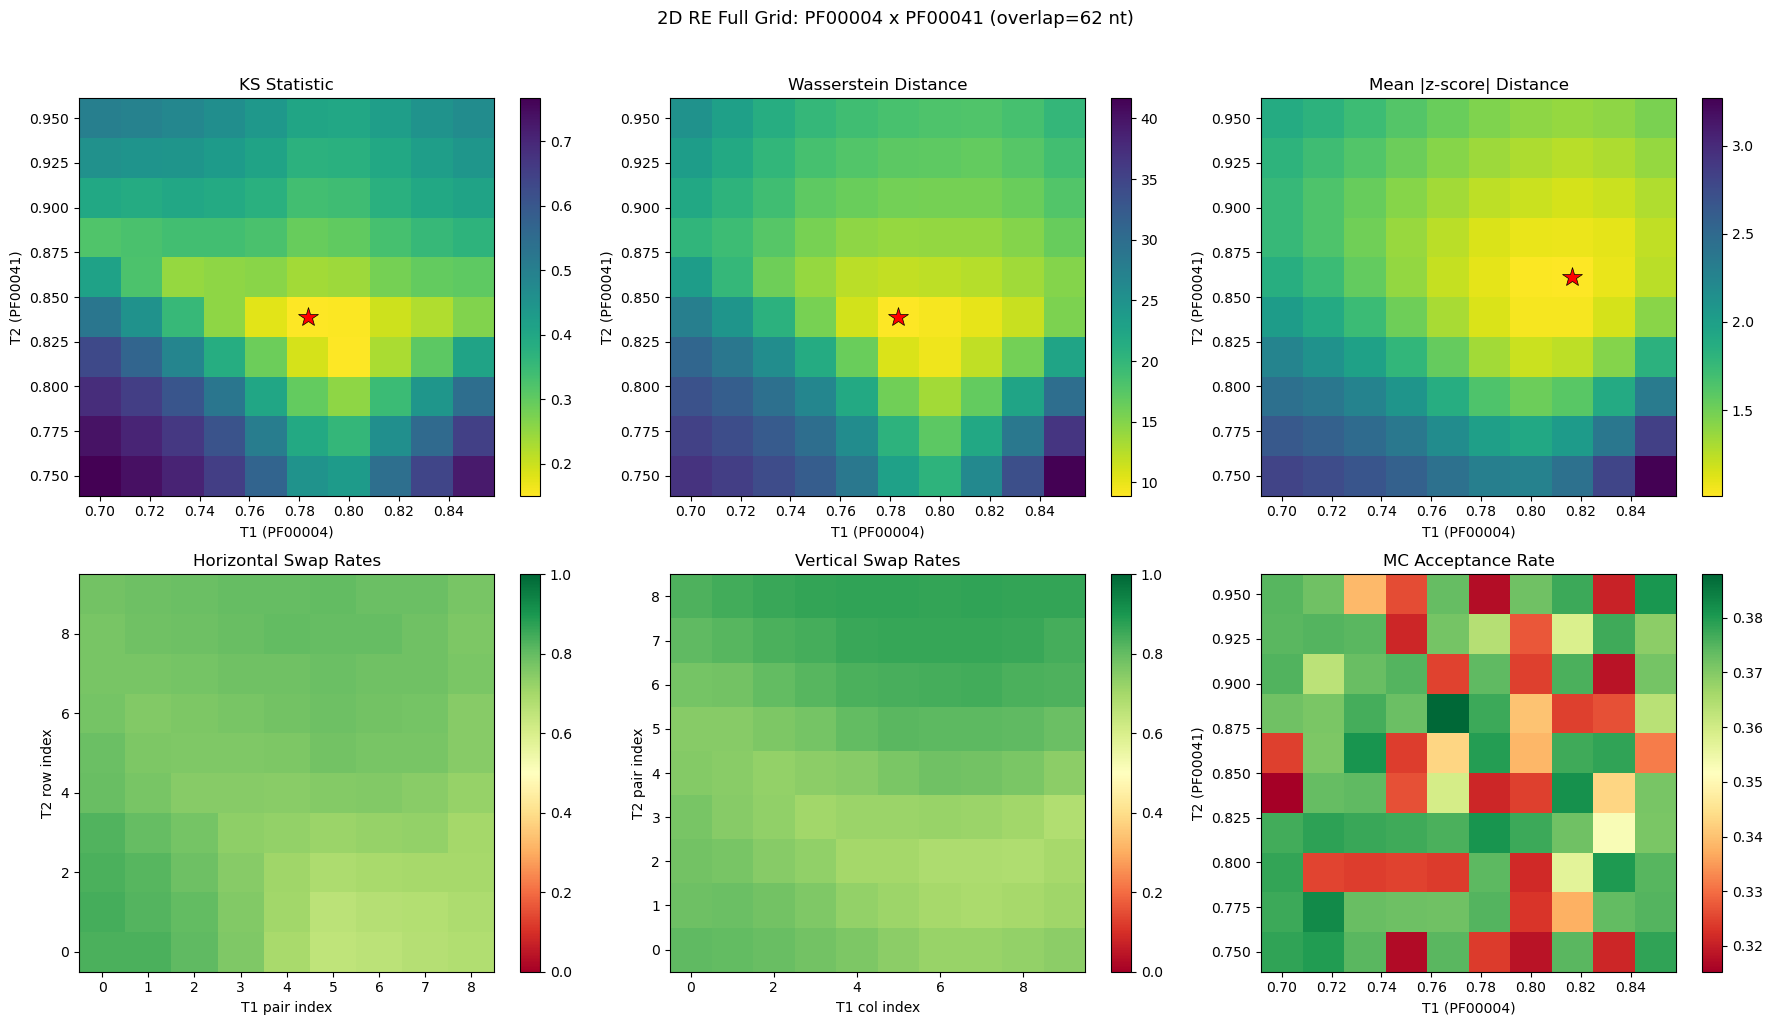

Saved re2d_heatmaps.png


In [33]:
# === Cell 4: Heatmaps ===

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# --- Top row: KS, Wasserstein, z-score heatmaps ---
for ax, grid, title, (bT1, bT2) in zip(
    axes[0],
    [ks_grid, wass_grid, zscore_grid],
    ["KS Statistic", "Wasserstein Distance", "Mean |z-score| Distance"],
    [(best_ks_T1, best_ks_T2),
     (best_wass_T1, best_wass_T2),
     (best_z_T1, best_z_T2)]
):
    pcm = ax.pcolormesh(T1_RANGE, T2_RANGE, grid, cmap="viridis_r", shading="auto")
    ax.plot(bT1, bT2, "r*", markersize=15, markeredgecolor="k", markeredgewidth=0.5)
    ax.set_xlabel(f"T1 ({PF1})")
    ax.set_ylabel(f"T2 ({PF2})")
    ax.set_title(title)
    fig.colorbar(pcm, ax=ax)

# --- Bottom row: swap rate maps + MC acceptance ---
# Horizontal swap rates
ax = axes[1, 0]
pcm = ax.pcolormesh(np.arange(n_t1 - 1), np.arange(n_t2),
                    result_2d['swap_rates_h'], cmap="RdYlGn", vmin=0, vmax=1,
                    shading="auto")
ax.set_xlabel("T1 pair index")
ax.set_ylabel("T2 row index")
ax.set_title("Horizontal Swap Rates")
fig.colorbar(pcm, ax=ax)

# Vertical swap rates
ax = axes[1, 1]
pcm = ax.pcolormesh(np.arange(n_t1), np.arange(n_t2 - 1),
                    result_2d['swap_rates_v'], cmap="RdYlGn", vmin=0, vmax=1,
                    shading="auto")
ax.set_xlabel("T1 col index")
ax.set_ylabel("T2 pair index")
ax.set_title("Vertical Swap Rates")
fig.colorbar(pcm, ax=ax)

# MC acceptance rates
ax = axes[1, 2]
pcm = ax.pcolormesh(T1_RANGE, T2_RANGE, result_2d['acceptance_grid'],
                    cmap="RdYlGn", shading="auto")
ax.set_xlabel(f"T1 ({PF1})")
ax.set_ylabel(f"T2 ({PF2})")
ax.set_title("MC Acceptance Rate")
fig.colorbar(pcm, ax=ax)

fig.suptitle(f"2D RE Full Grid: {PF1} x {PF2} (overlap={OVERLAP_LEN} nt)",
             fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig("re2d_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved re2d_heatmaps.png")

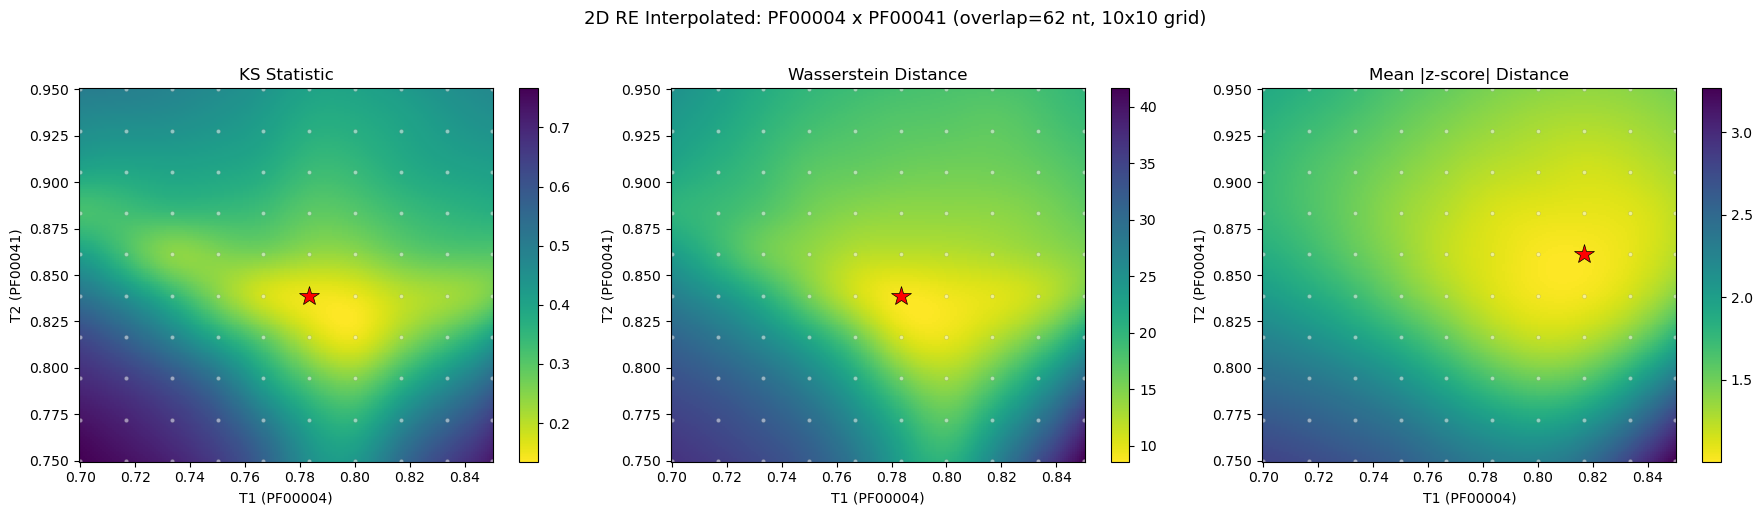

Saved re2d_heatmaps_interpolated.png


In [34]:
# === Cell 4b: Interpolated Heatmaps ===

from scipy.interpolate import RegularGridInterpolator

# Fine grid for interpolation
T1_fine = np.linspace(T1_MIN, T1_MAX, 200)
T2_fine = np.linspace(T2_MIN, T2_MAX, 200)
T1_mesh, T2_mesh = np.meshgrid(T1_fine, T2_fine)
query_pts = np.column_stack([T2_mesh.ravel(), T1_mesh.ravel()])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, grid, title, (bT1, bT2) in zip(
    axes,
    [ks_grid, wass_grid, zscore_grid],
    ["KS Statistic", "Wasserstein Distance", "Mean |z-score| Distance"],
    [(best_ks_T1, best_ks_T2),
     (best_wass_T1, best_wass_T2),
     (best_z_T1, best_z_T2)]
):
    interp = RegularGridInterpolator(
        (T2_RANGE, T1_RANGE), grid, method='cubic', bounds_error=False)
    grid_fine = interp(query_pts).reshape(T2_mesh.shape)

    pcm = ax.pcolormesh(T1_fine, T2_fine, grid_fine, cmap="viridis_r", shading="auto")
    # Overlay original grid points
    T1_pts, T2_pts = np.meshgrid(T1_RANGE, T2_RANGE)
    ax.scatter(T1_pts.ravel(), T2_pts.ravel(), c='white', s=8, alpha=0.5, edgecolors='gray', linewidths=0.3)
    ax.plot(bT1, bT2, "r*", markersize=15, markeredgecolor="k", markeredgewidth=0.5)
    ax.set_xlabel(f"T1 ({PF1})")
    ax.set_ylabel(f"T2 ({PF2})")
    ax.set_title(title)
    fig.colorbar(pcm, ax=ax)

fig.suptitle(f"2D RE Interpolated: {PF1} x {PF2} (overlap={OVERLAP_LEN} nt, {N_T2}x{N_T1} grid)",
             fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig("re2d_heatmaps_interpolated.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved re2d_heatmaps_interpolated.png")

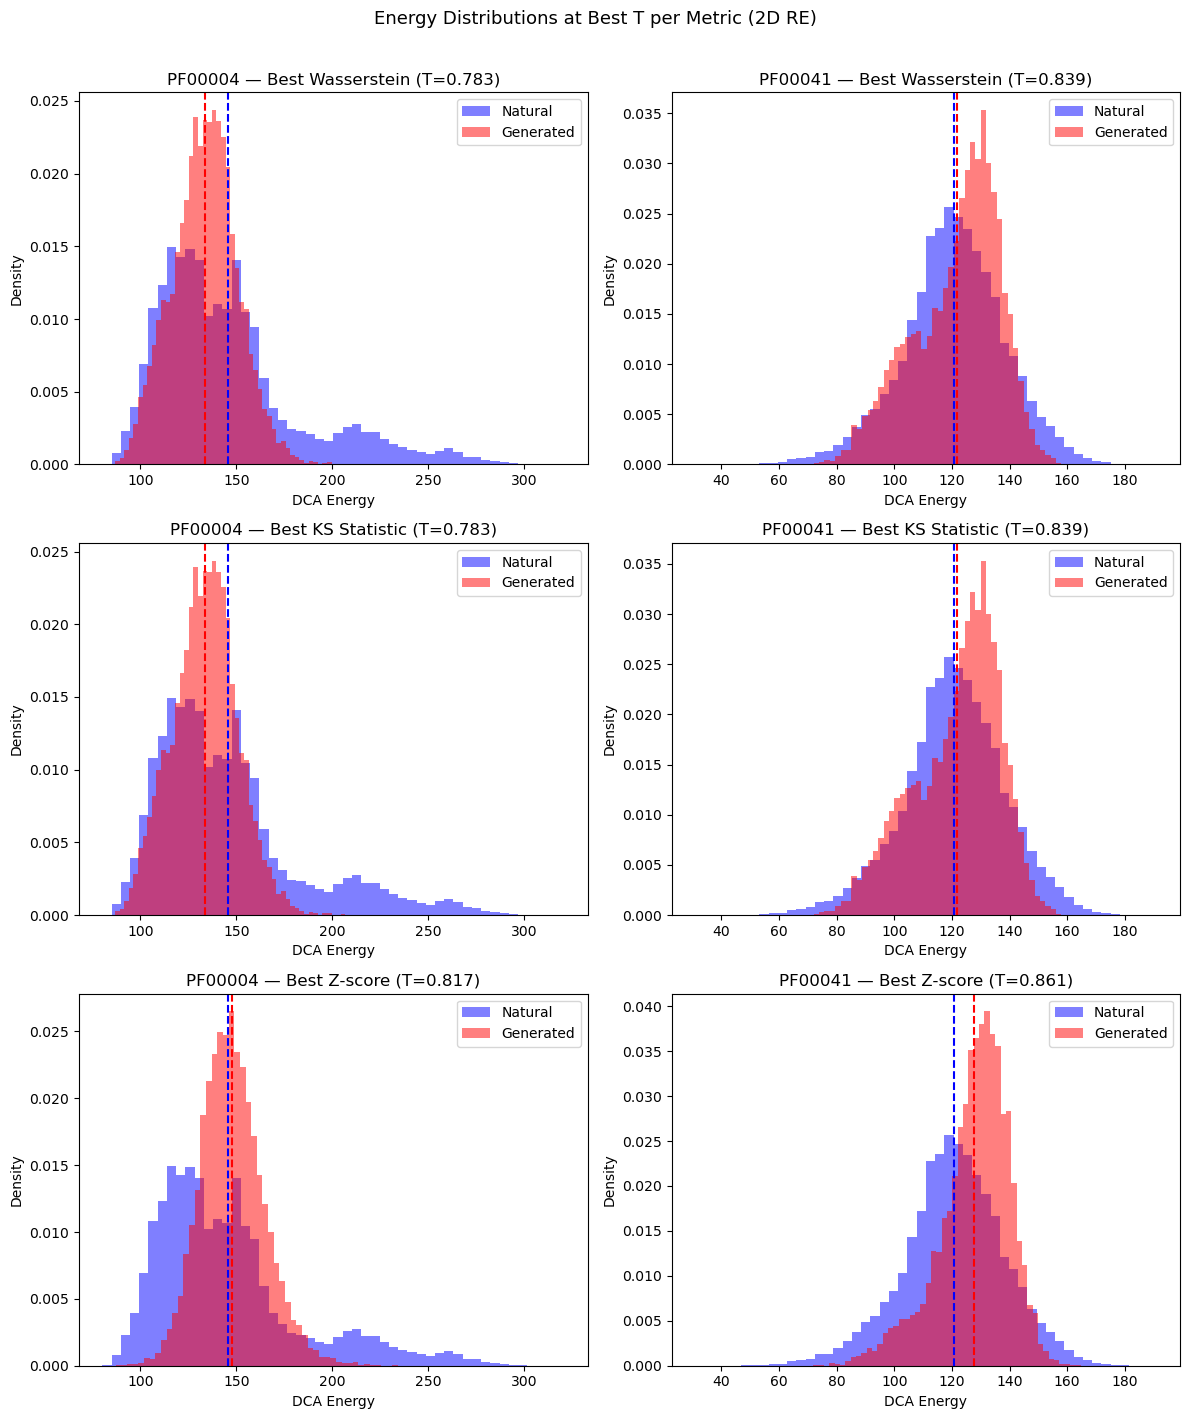

Saved re2d_energy_histograms.png


In [35]:
# === Cell 5: Energy Histograms at Best T (all three metrics) ===

best_points = [
    ("Wasserstein", best_wass_T1, best_wass_T2, wi, wj, best_wass_val),
    ("KS Statistic", best_ks_T1, best_ks_T2, ki, kj, best_ks_val),
    ("Z-score", best_z_T1, best_z_T2, zi, zj, best_z_val),
]

fig, axes = plt.subplots(3, 2, figsize=(12, 14))

for row, (metric_name, bT1, bT2, bi, bj, bval) in enumerate(best_points):
    E1_best = result_2d['E1_grid'][bi, bj]
    E2_best = result_2d['E2_grid'][bi, bj]

    for col, (nat_e, gen_e, pf, T_val) in enumerate([
        (nat_energies_1, E1_best, PF1, bT1),
        (nat_energies_2, E2_best, PF2, bT2),
    ]):
        ax = axes[row, col]
        ax.hist(nat_e, bins=50, density=True, alpha=0.5, color="blue", label="Natural")
        ax.hist(gen_e, bins=50, density=True, alpha=0.5, color="red", label="Generated")
        ax.axvline(np.mean(nat_e), color="blue", linestyle="--", linewidth=1.5)
        ax.axvline(np.mean(gen_e), color="red", linestyle="--", linewidth=1.5)
        ax.set_xlabel("DCA Energy")
        ax.set_ylabel("Density")
        ax.set_title(f"{pf} — Best {metric_name} (T={T_val:.3f})")
        ax.legend()

fig.suptitle(f"Energy Distributions at Best T per Metric (2D RE)", fontsize=13, y=1.01)
fig.tight_layout()
fig.savefig("re2d_energy_histograms.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved re2d_energy_histograms.png")

<>:49: SyntaxWarning: invalid escape sequence '\p'
<>:49: SyntaxWarning: invalid escape sequence '\p'
C:\Users\orson\AppData\Local\Temp\ipykernel_32228\2652282158.py:49: SyntaxWarning: invalid escape sequence '\p'
  f"Samples within $\pm 1\sigma$ (both): {within_1sigma:.1f}%\n"


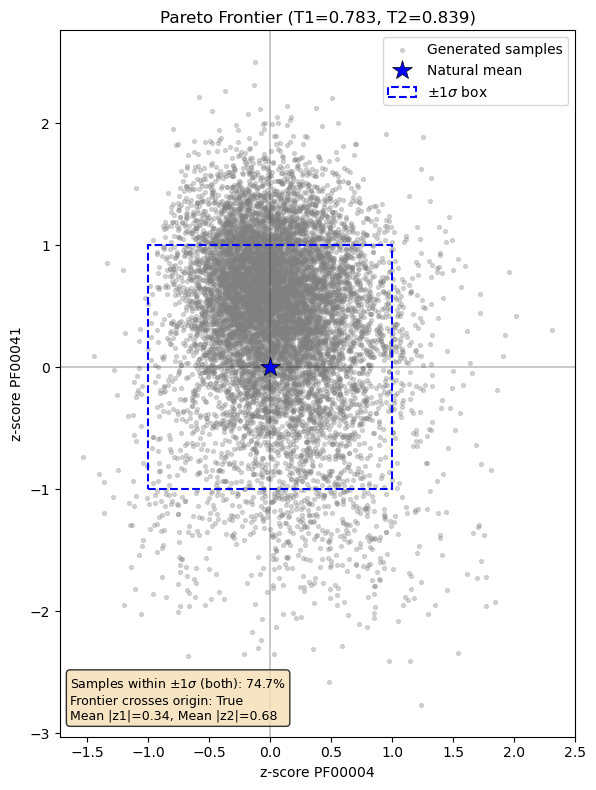

Saved re2d_pareto_frontier.png


In [36]:
# === Cell 6: Pareto Frontier ===

# Z-scores at best Wasserstein grid point
z1_det = (E1_best - mean_1) / std_1
z2_det = (E2_best - mean_2) / std_2

abs_z1 = np.abs(z1_det)
abs_z2 = np.abs(z2_det)

# Find Pareto frontier: non-dominated points in (|z1|, |z2|) space
sort_idx = np.argsort(abs_z1)
pareto_mask = np.zeros(len(z1_det), dtype=bool)
min_z2_so_far = np.inf
for k in sort_idx:
    if abs_z2[k] < min_z2_so_far:
        pareto_mask[k] = True
        min_z2_so_far = abs_z2[k]

pareto_abs_z1 = abs_z1[pareto_mask]
pareto_abs_z2 = abs_z2[pareto_mask]

fig, ax = plt.subplots(figsize=(8, 8))

# Scatter all samples
ax.scatter(z1_det, z2_det, s=8, alpha=0.3, c="gray", label="Generated samples")

# Natural mean at origin
ax.plot(0, 0, "b*", markersize=15, markeredgecolor="k",
        markeredgewidth=0.5, zorder=5, label="Natural mean")

# +/- 1 sigma box
rect = plt.Rectangle((-1, -1), 2, 2, fill=False, edgecolor="blue",
                      linestyle="--", linewidth=1.5, label=r"$\pm 1\sigma$ box")
ax.add_patch(rect)

ax.set_xlabel(f"z-score {PF1}")
ax.set_ylabel(f"z-score {PF2}")
ax.set_title(f"Pareto Frontier (T1={best_wass_T1:.3f}, T2={best_wass_T2:.3f})")
ax.legend(loc="upper right")
ax.set_aspect("equal")
ax.axhline(0, color="k", linewidth=0.3)
ax.axvline(0, color="k", linewidth=0.3)

# Summary stats
within_1sigma = np.sum((abs_z1 <= 1) & (abs_z2 <= 1)) / len(z1_det) * 100
frontier_crosses = np.any((pareto_abs_z1 <= 0.1) & (pareto_abs_z2 <= 0.1))

stats_text = (
    f"Samples within $\pm 1\sigma$ (both): {within_1sigma:.1f}%\n"
    f"Frontier crosses origin: {frontier_crosses}\n"
    f"Mean |z1|={np.mean(abs_z1):.2f}, Mean |z2|={np.mean(abs_z2):.2f}"
)
ax.text(0.02, 0.02, stats_text, transform=ax.transAxes, fontsize=9,
        verticalalignment="bottom",
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))

fig.tight_layout()
fig.savefig("re2d_pareto_frontier.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved re2d_pareto_frontier.png")